In [71]:
import pandas as pd
import numpy as np
import os

pd.set_option("display.max_columns", None)  # no column truncation
pd.set_option("display.width", 0)  # prevents line wrapping

In [72]:
df = pd.read_parquet("../data/raw/combined_csv/data_prep_kz.parquet",engine="pyarrow")
df["FECHA"] = pd.to_datetime(df["FECHA"], format="%Y-%m-%d")
daily_df = df.copy()
df["FECHA"] = df["FECHA"].dt.strftime("%Y-%U")
weekly_df = pd.DataFrame({"FECHA": df["FECHA"].dropna().sort_values().unique()})
df.head()

,NUMERO DE ACEPTACION,RUT PROBABLE IMPORTADOR,PAIS DE ORIGEN,PUERTO DE EMBARQUE,PUERTO DE DESEMBARQUE,COMPANIA DE TRANSPORTE,TIPO DE BULTO,CLAUSULA,CANTIDAD DE BULTO,CANTIDAD UNIDADES FISICAS,UNIDAD DE MEDIDA FISICA,FECHA,FECHA_TRANS,DIFF_DAYS,FOB_POR_BULTO,FLETE_POR_BULTO,SEGURO_POR_BULTO,PESO BRUTO POR CONTENEDOR,ITEMS POR CONTENEDOR
0,20966331,76056375,ECUADOR,OTROS PUERTOS MEXICO,SAN ANTONIO,HAPAG-LLOYD,CONTENEDOR REFRIGERADO 40,FOB,2,1080.0,CAJAS,2024-01,2024-01-30,-19.0,3240.00,654.0,64.80,10902.6,0.5
1,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,300.0,CAJA,2024-00,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0
2,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,1400.0,CAJA,2024-00,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0
3,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,50.0,CAJA,2024-00,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0
4,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,6000.0,KN,2024-00,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0


In [73]:
df.shape

(5595152, 19)

In [74]:
df['PUERTO DE EMBARQUE'].unique()

array(['OTROS PUERTOS MEXICO', 'HONG KONG', 'SHANGAI',
       'OTROS PTOS.DE CHINA', 'CALLAO', 'BUENAVENTURA',
       'OTROS PTOS. COLOMBIA', 'HAMBURGO', 'GUAYAQUIL', 'AMBERES',
       'OTROS PTOS. PANAMA', 'CRISTOBAL', 'BALBOA', 'OTROS PTOS.BRASIL',
       'NEW YORK', 'ROTTERDAM', 'MIAMI', 'KAOHSIUNG', 'BUSAN CY (PUSAN)',
       'OTROS PTOS.AMERICA', 'MANZANILLO', 'OTROS PTOS.PORTUGAL',
       'OTROS PTOS.EUROPA', 'SAVANAH', 'OTROS PTOS. ECUADOR', 'GENOVA',
       'DAIREN', 'VALENCIA', 'BARCELONA', 'COSTA DEL PACIFICO',
       'OTROS PTO.ASIATICOS', 'OTROS PTOS.ESPANA', 'LONDRES',
       'OTROS PTO.BELGICA', 'OTROS PTOS. DE PERU', 'ALGECIRAS',
       'SALVADOR', 'OAKLAND', 'OTROS PTOS.DE ITALIA', 'SANTOS',
       'OTROS PTOS.ALEMANIA', 'PHILADELPHIA', 'RIO DE JANEIRO',
       'OTROS PTOS.DE COREA', 'LOS ANGELES', 'SEATTLE', 'EVERGLADES',
       'CHARLESTON', 'SAO PAULO', 'OTROS ANT.HOLANDESA', 'LE HAVRE',
       'OTROS PTOS.INGLATERR', 'OTROS PTOS. CHILENOS', 'COPENHAGEN',
       'VAL

In [75]:
grouped_coasts = {
    'GALVESTON': 'NAE',
    'OTROS PTOS VENEZUELA': 'SAE',
    'PUERTO ANGAMOS': 'SAW',
    'SAN  ANTONIO': 'SAW',
    'OTROS PTOS.INGLATERR': 'NE',
    'OTROS PTOS.AMERICA': 'NAE',
    'LISBOA': 'SE',
    'ZEEBRUGGE': 'NE',
    'NAPOLES': 'SE',
    'DAIREN': 'FE',
    'SALVADOR': 'SAE',
    'CHARLESTON': 'NAE',
    'KEELUNG': 'FE',
    'OTROS PTOS. CHILENOS': 'SAW',
    'OTROS PTOS.DE ITALIA': 'SE',
    'NEW HAVEN': 'NAE',
    'OTROS PTOS. COLOMBIA': 'SAW',
    'HOUSTON': 'NAE',
    'OTROS PTOS. DE PERU': 'SAW',
    'SALERNO': 'SE',
    'OTROS PTOS.EUROPA': 'NE',
    'CUTTER COVE': 'NAW',
    'PALENA CARRENLEUFU': 'SAW',
    'SEATTLE': 'NAW',
    'LOS ANGELES': 'NAW',
    'RIJEKA': 'SE',
    'CUXHAVEN': 'NE',
    'OTROS PTOS.HOLANDA': 'NE',
    'AMSTERDAM': 'NE',
    'TORONTO': 'NAE',
    'PORT ARTHUR': 'NAE',
    'OTROS PTOS.TAIWAN': 'FE',
    'LIECHTENSTEIN': 'NE',
    'OTROS PTOS.BRASIL': 'SAE',
    'MENDOZA': 'SAE',
    'OTROS PTOS. ECUADOR': 'SAW',
    'BALTIMORE': 'NAE',
    'CORONEL': 'SAW',
    'AEROPUERTO COM. A. MERINO B.': 'SAW',
    'OTROS PTOS PORTUGAL': 'SE',
    'OTROS PTOS.PORTUGAL': 'SE',
    'PORTLAND': 'NAW',
    'KOTKA': 'NE',
    'OULO': 'NE',
    'OSLO': 'NE',
    'OTROS PTO.NORUEGA': 'NE',
    'HELSINKI': 'NE',
    'SANTOS': 'SAE',
    'BILBAO': 'SE',
    'GOTEMBURGO': 'NE',
    'FRANKFURT': 'NE',
    'OLDENBURG': 'NE',
    'LE HAVRE': 'NE',
    'YOKOHAMA': 'FE',
    'CRISTOBAL': 'NAE',
    'COSTA DEL PACIFICO': 'NAW',
    'GNL MEJILLONES': 'SAW',
    'CURACAO': 'NAE',
    'OTROS PTOS. CHILENOS': 'SAW',
    'SAN FRANCISCO': 'NAW',
    'ROSTOCK': 'NE',
    'BARRANQUILLA': 'NAE',
    'CIUDAD DEL CABO': 'AF',
    'HELSIMBORG': 'NE',
    'AUGUSTA': 'SE',
    'OTROS PTOS. PANAMA': 'NAE',
    'OTROS PTOS.ALEMANIA': 'NE',
    'OTROS PTOS BULGARIA': 'SE',
    'OTROS PTOS.SUECIA': 'NE',
    'PARANAGUA': 'SAE',
    'OSAKA': 'FE',
    'OTROS PTO.SUD AFRIC': 'AF',
    'VANCOUVER': 'NAW',
    'SALINAS': 'SAW',
    'COLUMBRES': 'SE',
    'NEW YORK': 'NAE',
    'PUERTOS DEL GOLFO': 'NAE',
    'COSTA DE ATLANTICO': 'NAE',
    'TAMPA': 'NAE',
    'QUEBEC': 'NAE',
    'OTROS PUERTOS CANADA': 'NAE',
    'AMBERES': 'NE',
    'LIVERPOOL': 'NE',
    'SAVONA': 'SE',
    'OTROS PTOS.ESPANA': 'SE',
    'LIORNA,LIVORNO': 'SE',
    'OTROS PTO.OCEANIA': 'OC',
    'NORFOLK': 'NAE',
    'VALENCIA': 'SE',
    'COLON': 'NAE',
    'OTROS PTOS.FRANCIA': 'SE',
    'OTROS PTOS.ARGENTINA': 'SAE',
    'VERACRUZ': 'NAE',
    'BREMEN': 'NE',
    'OTROS PTOS PORTUGAL': 'SE',
    'OTROS PTOS.ESPANA': 'SE',
    'AALBORG': 'NE',
    'OTROS PTOS.JAPONESES': 'FE',
    'BUENAVENTURA': 'SAW',
    'OTROS PTO.BANGLADESH': 'ME',
    'OTROS PTOS. ECUADOR ': 'SAW',
    'OTROS PTOS.TAIWAN ': 'FE',
    'COATZACOALES': 'NAE',
    'PANAMA': 'NAW',
    'OTROS PTOS.DE COREA': 'FE',
    'OTROS PTOS.ARGENTINA ': 'SAE',
    'IQUIQUE': 'SAW',
    'RIO DE JANEIRO': 'SAE',
    'RIO GRANDE DEL SUR': 'SAE',
    'BUENOS AIRES': 'SAE',
    'OTROS PTOS.URUGUAY': 'SAE',
    'MONTEVIDEO': 'SAE',
    'BAHIA BLANCA': 'SAE',
    'SAO PAULO': 'SAE',
    'ARICA': 'SAW',
    'MEJILLONES': 'SAW',
    'PATILLOS': 'SAW',
    'CALDERA': 'SAW',
    'SAN VICENTE': 'SAW',
    'LIRQUEN': 'SAW',
    'TALCAHUANO': 'SAW',
    'VALPARAISO': 'SAW',
    'SAN  ANTONIO': 'SAW',
    'GUAYACAN': 'SAW',
    'OTROS PTOS. DE PERU': 'SAW',
    'CALLAO': 'SAW',
    'ILO': 'SAW',
    'GUAYAQUIL': 'SAW',
    'OTROS PTOS. ECUADOR': 'SAW',
    'OTROS PTOS.BRASIL': 'SAE',
    'SALVADOR': 'SAE',
    'SANTOS': 'SAE',
    'PARANAGUA': 'SAE',
    'RIO GRANDE DEL SUR': 'SAE',
    'AMSTERDAM': 'NE',
    'ROTTERDAM': 'NE',
    'HAMBURGO': 'NE',
    'LONDRES': 'NE',
    'LE HAVRE ': 'NE',
    'LA PALLICE': 'NE',
    'ZEEBRUGGE ': 'NE',
    'BREMEN ': 'NE',
    'CUXHAVEN ': 'NE',
    'ROSTOCK ': 'NE',
    'FRANKFURT ': 'NE',
    'NUREMBERG': 'NE',
    'OLDENBURG ': 'NE',
    'OTROS PTOS.ALEMANIA ': 'NE',
    'OTROS PTOS.HOLANDA ': 'NE',
    'OTROS PTO.BELGICA': 'NE',
    'OTROS PTOS.INGLATERR ': 'NE',
    'COPENHAGEN': 'NE',
    'AARHUS': 'NE',
    'AALBORG ': 'NE',
    'GOTEMBURGO ': 'NE',
    'HELSIMBORG ': 'NE',
    'OSLO ': 'NE',
    'STAVANGER': 'NE',
    'HELSINKI ': 'NE',
    'KOTKA ': 'NE',
    'OULO ': 'NE',
    'OTROS PTO.NORUEGA ': 'NE',
    'OTROS  PTO.DINAMARCA': 'NE',
    'OTROS PTOS.SUECIA ': 'NE',
    'OTROS PTO.FINLANDIA': 'NE',
    'GENOVA': 'SE',
    'VALENCIA ': 'SE',
    'BARCELONA': 'SE',
    'BILBAO ': 'SE',
    'ALGECIRAS': 'SE',
    'CADIZ': 'SE',
    'SEVILLA': 'SE',
    'LISBOA ': 'SE',
    'SETUBAL': 'SE',
    'MARSELLA': 'SE',
    'LIORNA,LIVORNO ': 'SE',
    'SAVONA ': 'SE',
    'AUGUSTA ': 'SE',
    'NAPOLES ': 'SE',
    'SALERNO ': 'SE',
    'CONSTANZA': 'SE',
    'VARNA': 'SE',
    'RIJEKA ': 'SE',
    'OTROS PTOS.PORTUGAL ': 'SE',
    'OTROS PTOS.ESPANA ': 'SE',
    'OTROS PTOS.DE ITALIA ': 'SE',
    'OTROS PTOS.FRANCIA ': 'SE',
    'OTROS PTOS BULGARIA ': 'SE',
    'OTROS PTO.DE RUMANIA': 'SE',
    'HONG KONG': 'FE',
    'SHANGAI': 'FE',
    'OTROS PTOS.DE CHINA': 'FE',
    'DAIREN ': 'FE',
    'KAOHSIUNG': 'FE',
    'KEELUNG ': 'FE',
    'OTROS PTOS.TAIWAN  ': 'FE',
    'BUSAN CY (PUSAN)': 'FE',
    'OTROS PTOS.DE COREA ': 'FE',
    'YOKOHAMA ': 'FE',
    'KOBE': 'FE',
    'OSAKA ': 'FE',
    'NAGOYA': 'FE',
    'SHIMIZUI': 'FE',
    'FUKUYAMA': 'FE',
    'MOJI': 'FE',
    'OTROS PTOS.JAPONESES ': 'FE',
    'MANILA': 'FE',
    'OTROS PTOS.FILIPINAS': 'FE',
    'OTROS PTO.SINGAPURE': 'FE',
    'OTROS PTO.ASIATICOS': 'FE',
    'OTROS PTO.IRAN NO ES': 'ME',
    'OTROS PTO.INDIA NO E': 'FE',
    'CALCUTA': 'FE',
    'OTROS PTO.BANGLADESH ': 'FE',
    'DURBAM': 'AF',
    'CIUDAD DEL CABO ': 'AF',
    'OTROS PTO.DE AFRICA': 'AF',
    'OTROS PTO.SUD AFRIC ': 'AF',
    'SIDNEY': 'OC',
    'ADELAIDA': 'OC',
    'PREMANTLE': 'OC',
    'OTROS PTO.AUSTRALIA': 'OC',
    'OTROS PTO.OCEANIA ': 'OC',
    'LONG BEACH': 'NAW',
    'OAKLAND': 'NAW',
    'SEATTLE ': 'NAW',
    'SAN DIEGO': 'NAW',
    'SAN FRANCISCO ': 'NAW',
    'PORTLAND ': 'NAW',
    'VANCOUVER ': 'NAW',
    'BALBOA': 'NAW',
    'MANZANILLO': 'NAW',
    'MAZATLAN': 'NAW',
    'GUAYMAS': 'NAW',
    'COSTA DEL PACIFICO ': 'NAW',
    'OTROS PUERTOS MEXICO': 'NAW',
    'NEW YORK ': 'NAE',
    'MIAMI': 'NAE',
    'PHILADELPHIA': 'NAE',
    'EVERGLADES': 'NAE',
    'CHARLESTON ': 'NAE',
    'SAVANAH': 'NAE',
    'HOUSTON ': 'NAE',
    'NORFOLK ': 'NAE',
    'BALTIMORE ': 'NAE',
    'SAINT JOHN': 'NAE',
    'MOBILE': 'NAE',
    'NEW ORLEANS': 'NAE',
    'JACKSONVILLE': 'NAE',
    'TAMPA ': 'NAE',
    'PORT ARTHUR ': 'NAE',
    'GALVESTON ': 'NAE',
    'BOSTON': 'NAE',
    'HALIFAX': 'NAE',
    'MONTREAL': 'NAE',
    'QUEBEC ': 'NAE',
    'TORONTO ': 'NAE',
    'PITTSBURGH': 'NAE',
    'MILWAUKEE': 'NAE',
    'NEW HAVEN ': 'NAE',
    'COLON ': 'NAE',
    'CRISTOBAL ': 'NAE',
    'CURACAO ': 'NAE',
    'PUERTOS DEL GOLFO ': 'NAE',
    'GOLFO DE MEXICO': 'NAE',
    'COATZACOALES ': 'NAE',
    'VERACRUZ ': 'NAE',
    'TAMPICO ': 'NAE',
    'OTROS PUERTOS CANADA ': 'NAE',
    'OTROS PUERTOS EE.UU.': 'NAE',
    'EEUU': 'NAE',
    'BARRANQUILLA ': 'NAE',
    'LA GUAYRA': 'NAE',
    'OTROS ANT.HOLANDESA': 'NAE',
    'PANAMA ': 'NAW',
    'COSTA DE ATLANTICO ': 'NAE',
    'OTROS PTOS. COLOMBIA ': 'SAW',
    'AEROPUERTO COM. A. MERINO B. ': 'SAW',
    'CORONEL ': 'SAW',
    'COLUMBRES ': 'SE',
    '-': 'NAE',
    'LIECHTENSTEIN ': 'NE',
    'CUTTER COVE ': 'NAW',
    'TERR. ANTARTICO CHILE': 'SAW',
    'OTROS PTO.DE RUMANIA ': 'SE',
    'OTROS PTO.FINLANDIA ': 'NE',
    'OTROS  PTO.DINAMARCA ': 'NE',
    'OTROS PTOS BULGARIA  ': 'SE',
    'OTROS PTOS.DE CHINA ': 'FE',
    'HONG KONG ': 'FE',
    'JURELES': 'NAW',
    'TAMPICO': 'NAE',
    'ANTOFAGASTA': 'SAW',
    'URUGUAY': 'SAE',
    'ZONA FRANCA PUNTA ARENAS': 'SAW',
    'SAN PEDRO DE ATACAMA': 'SAW',
    'ZONA FRANCA IQUIQUE': 'SAW',
    'OLLAGUE': 'SAW',
    'POSEIDON': 'SAW',
    'PASO GUANACO SONSO': 'SAW',
    'SOCOMPA': 'SAW',
    'CABO NEGRO': 'SAW',
}
df['coast'] = df['PUERTO DE EMBARQUE'].map(grouped_coasts)


In [76]:
df.drop(df[(df['coast'] == 'ME') | (df['coast'] == 'AF') | (df['coast'] == 'OC')].index, inplace= True)
df.shape

(5592227, 20)

In [77]:
df.columns

Index(['NUMERO DE ACEPTACION', 'RUT PROBABLE IMPORTADOR', 'PAIS DE ORIGEN',
       'PUERTO DE EMBARQUE', 'PUERTO DE DESEMBARQUE', 'COMPANIA DE TRANSPORTE',
       'TIPO DE BULTO', 'CLAUSULA', 'CANTIDAD DE BULTO',
       'CANTIDAD UNIDADES FISICAS', 'UNIDAD DE MEDIDA FISICA', 'FECHA',
       'FECHA_TRANS', 'DIFF_DAYS', 'FOB_POR_BULTO', 'FLETE_POR_BULTO',
       'SEGURO_POR_BULTO', 'PESO BRUTO POR CONTENEDOR', 'ITEMS POR CONTENEDOR',
       'coast'],
      dtype='object')

In [78]:
df.groupby('coast').agg({'FLETE_POR_BULTO':'mean'}).sort_values(by='FLETE_POR_BULTO')

,FLETE_POR_BULTO
coast,
NAW,2545.879403
SAW,2768.176361
NAE,2830.646444
NE,2988.379989
FE,4101.444702
SE,4144.638486
SAE,4249.207079


In [79]:
df.CLAUSULA.unique()
clausula_dict = {
    "CIF": "CD",
    "CYS": "CD",
    "CFR": "CFR",
    "FOB": "F",
    "FAS": "F",
    "EXW": "F",
    "SIN CLAUSULA": "OTRO",
    "OTRO": "OTRO",
    "DDP": "CD",
}
df.CLAUSULA = df.CLAUSULA.map(clausula_dict)

<Axes: xlabel='COMPANIA DE TRANSPORTE'>

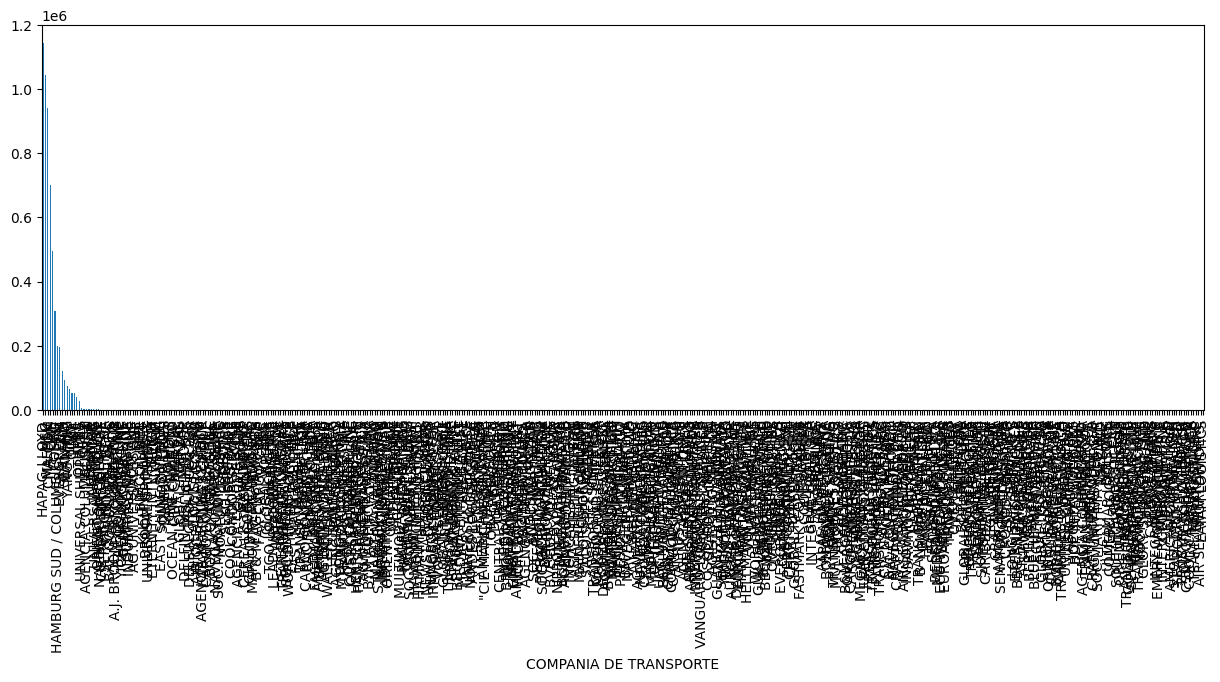

In [80]:
df["COMPANIA DE TRANSPORTE"].value_counts().plot(kind="bar", figsize=(15, 5))

<Axes: xlabel='COMPANIA DE TRANSPORTE'>

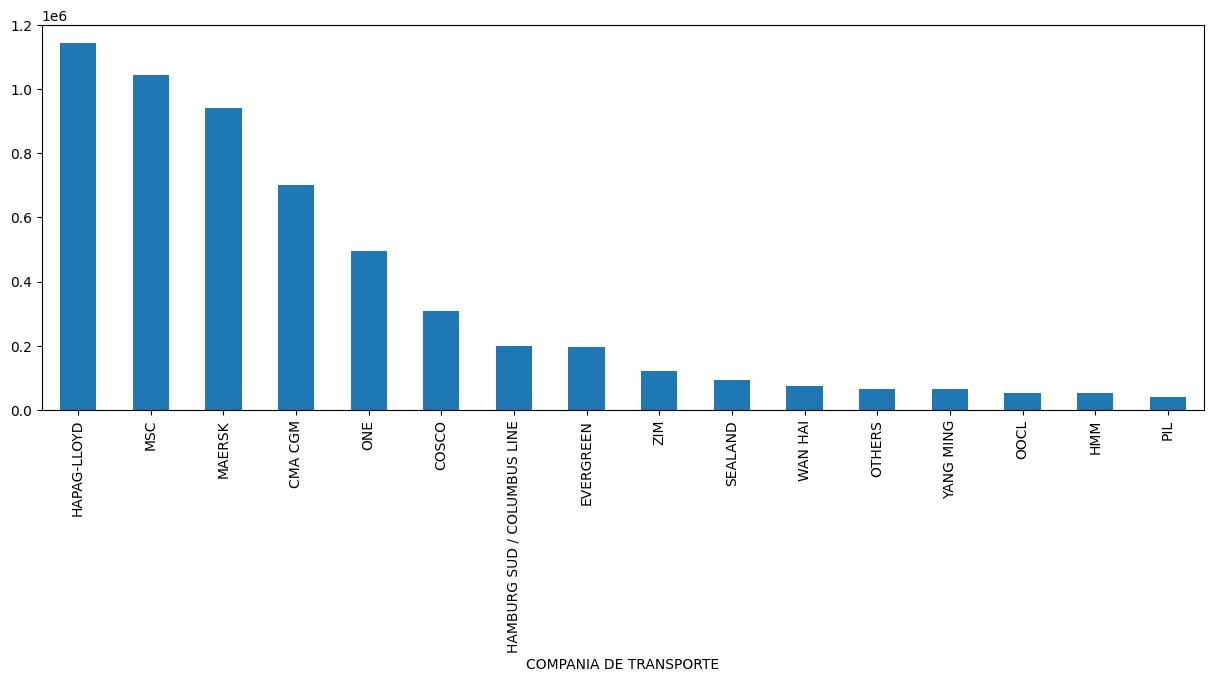

In [81]:
frecuencias = df["COMPANIA DE TRANSPORTE"].value_counts(normalize=True) * 100

# Identificar los que representan menos del 0.5%
menos_frecuentes = frecuencias[frecuencias < 0.5].index
df["COMPANIA DE TRANSPORTE"] = np.where(
    df["COMPANIA DE TRANSPORTE"].isin(menos_frecuentes),
    "OTHERS",
    df["COMPANIA DE TRANSPORTE"],
)
df["COMPANIA DE TRANSPORTE"] = np.where(
    df["COMPANIA DE TRANSPORTE"] == "NO EXISTE", "OTHERS", df["COMPANIA DE TRANSPORTE"]
)
df["COMPANIA DE TRANSPORTE"].value_counts().plot(kind="bar", figsize=(15, 5))

In [82]:
df["TIPO DE BULTO"].value_counts()
df["TIPO DE BULTO"] = df["TIPO DE BULTO"].map(
    {
        "CONTENEDOR 40": 0,
        "CONTENEDOR 20": 0,
        "CONTENEDOR NO REFRIGERADO": 0,
        "CONTENEDOR REFRIGERADO 40": 2,
        "CONTENEDOR REFRIGERADO 20": 1,
    }
)
container_type_container_count = (
    df.groupby("FECHA")["TIPO DE BULTO"].sum().reset_index()
)
container_type_container_count

,FECHA,TIPO DE BULTO
0,2022-00,2
1,2022-01,6440
2,2022-02,6291
3,2022-03,5196
4,2022-04,5787
...,...,...
154,2024-48,4296
155,2024-49,4636
156,2024-50,5072
157,2024-51,4013


In [83]:
df["PAIS DE ORIGEN"].value_counts()

PAIS DE ORIGEN
CHINA                            2640277
U.S.A                             504923
ALEMANIA                          246076
ORIGEN O DESTINO NO PRECISADO     232922
MEXICO                            187684
                                  ...   
DOMINICA                               1
UGANDA                                 1
LIBERIA                                1
GUYANA                                 1
NAMIBIA                                1
Name: count, Length: 161, dtype: int64

In [84]:
frecuencias = df["PAIS DE ORIGEN"].value_counts(normalize=True) * 100

# Identificar los que representan menos del 0.5%
menos_frecuentes = frecuencias[frecuencias < 1.5].index
df2 = df.copy()
df["PAIS DE ORIGEN"] = np.where(
    df["PAIS DE ORIGEN"].isin(menos_frecuentes), "OTHERS", df["PAIS DE ORIGEN"]
)
print(df["PAIS DE ORIGEN"].nunique())
df["PAIS DE ORIGEN"].value_counts()

13


PAIS DE ORIGEN
CHINA                            2640277
OTHERS                            908306
U.S.A                             504923
ALEMANIA                          246076
ORIGEN O DESTINO NO PRECISADO     232922
MEXICO                            187684
ESPANA                            181631
FRANCIA                           160452
ITALIA                            148284
COLOMBIA                          103469
VIETNAM                           101239
INDIA                              92679
PERU                               84285
Name: count, dtype: int64

In [85]:
clausula_container_count = (
    df.groupby(["FECHA", "CLAUSULA"])["CANTIDAD DE BULTO"].sum().reset_index()
)
pivot_clausula_count = (
    clausula_container_count.pivot(
        index="FECHA", columns="CLAUSULA", values="CANTIDAD DE BULTO"
    )
    .fillna(0)
    .reset_index()
)
price_per_coast_count = (
    df.groupby(["FECHA", "coast"])["FLETE_POR_BULTO"]
    .mean()
    .reset_index()
)
price_per_coast_count = price_per_coast_count.pivot(
    index="FECHA", columns="coast", values="FLETE_POR_BULTO"
).interpolate(method='linear', limit_direction='both')

company_container_count = (
    df.groupby(["FECHA", "COMPANIA DE TRANSPORTE"])["CANTIDAD DE BULTO"]
    .sum()
    .reset_index()
)
pivot_company_count = (
    company_container_count.pivot(
        index="FECHA", columns="COMPANIA DE TRANSPORTE", values="CANTIDAD DE BULTO"
    )
    .fillna(0)
    .reset_index()
)
container_country_count = (
    df.groupby(["FECHA", "PAIS DE ORIGEN"])["CANTIDAD DE BULTO"].sum().reset_index()
)
pivot_country_count = (
    container_country_count.pivot(
        index="FECHA", columns="PAIS DE ORIGEN", values="CANTIDAD DE BULTO"
    )
    .fillna(0)
    .reset_index()
)
pivot_country_count

PAIS DE ORIGEN,FECHA,ALEMANIA,CHINA,COLOMBIA,ESPANA,FRANCIA,INDIA,ITALIA,MEXICO,ORIGEN O DESTINO NO PRECISADO,OTHERS,PERU,U.S.A,VIETNAM
0,2022-00,12.0,74.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,30.0,0.0
1,2022-01,3527.0,34838.0,1968.0,2674.0,2282.0,1440.0,1564.0,1570.0,3140.0,9988.0,626.0,4886.0,681.0
2,2022-02,3186.0,46978.0,1114.0,2872.0,1905.0,1410.0,959.0,3778.0,2070.0,11272.0,771.0,6126.0,1117.0
3,2022-03,1867.0,42974.0,721.0,1631.0,1211.0,1192.0,976.0,2130.0,5689.0,10744.0,696.0,6109.0,611.0
4,2022-04,2862.0,44870.0,639.0,2155.0,1068.0,662.0,2134.0,1772.0,4682.0,9361.0,840.0,4541.0,830.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,2024-48,3063.0,36641.0,940.0,2092.0,1599.0,1395.0,1638.0,2286.0,1671.0,10506.0,1305.0,6762.0,1650.0
155,2024-49,2835.0,37390.0,1249.0,1143.0,1370.0,1158.0,1280.0,2424.0,1625.0,11166.0,995.0,7648.0,1899.0
156,2024-50,5424.0,44692.0,1743.0,3375.0,2904.0,1608.0,2969.0,1745.0,1645.0,13157.0,1087.0,8087.0,1253.0
157,2024-51,2174.0,37546.0,1429.0,1876.0,1849.0,1086.0,1524.0,2506.0,1242.0,10124.0,1144.0,3838.0,1144.0


In [86]:
weekly_df.head()

,FECHA
0,2022-00
1,2022-01
2,2022-02
3,2022-03
4,2022-04


In [ ]:
quantity_daily = df.groupby("FECHA")["CANTIDAD DE BULTO"].sum().reset_index()
rut_diario = df.groupby("FECHA")["RUT PROBABLE IMPORTADOR"].nunique().reset_index()
rut_diario.rename(
    columns={"RUT PROBABLE IMPORTADOR": "RUTS_UNICOS_DIARIOS"}, inplace=True
)
weekly_df = pd.merge(weekly_df, rut_diario, how="outer", on="FECHA")
weekly_df = pd.merge(weekly_df, pivot_clausula_count, how="outer", on="FECHA")
weekly_df = pd.merge(weekly_df, pivot_company_count, how="outer", on="FECHA")
weekly_df = pd.merge(weekly_df, quantity_daily, how="outer", on="FECHA")
weekly_df = pd.merge(weekly_df, container_type_container_count, how="outer", on="FECHA")
weekly_df = pd.merge(weekly_df, pivot_country_count, how="outer", on="FECHA")
weekly_df = pd.merge(weekly_df, price_per_coast_count, how="outer", on="FECHA")

cols = [
    "DIFF_DAYS",
    "FOB_POR_BULTO",
    "SEGURO_POR_BULTO",
    "FLETE_POR_BULTO",
    "PESO BRUTO POR CONTENEDOR",
    "ITEMS POR CONTENEDOR",
]
agg_funcs = ["mean", "max", "std"]

for col in cols:
    agg_df = df.groupby("FECHA")[col].agg(agg_funcs).reset_index()
    agg_df.columns = ["FECHA"] + [f"{func.upper()}_{col}" for func in agg_funcs]
    weekly_df = pd.merge(weekly_df, agg_df, how="outer", on="FECHA")
weekly_df.drop(0, inplace=True).reset_index(drop=True, inplace=True)

,FECHA,RUTS_UNICOS_DIARIOS,CD,CFR,F,OTRO,CMA CGM,COSCO,EVERGREEN,HAMBURG SUD / COLUMBUS LINE,HAPAG-LLOYD,HMM,MAERSK,MSC,ONE,OOCL,OTHERS_x,PIL,SEALAND,WAN HAI,YANG MING,ZIM,CANTIDAD DE BULTO,TIPO DE BULTO,ALEMANIA,CHINA,COLOMBIA,ESPANA,FRANCIA,INDIA,ITALIA,MEXICO,ORIGEN O DESTINO NO PRECISADO,OTHERS_y,PERU,U.S.A,VIETNAM,FE,NAE,NAW,NE,SAE,SAW,SE,MEAN_DIFF_DAYS,MAX_DIFF_DAYS,STD_DIFF_DAYS,MEAN_FOB_POR_BULTO,MAX_FOB_POR_BULTO,STD_FOB_POR_BULTO,MEAN_SEGURO_POR_BULTO,MAX_SEGURO_POR_BULTO,STD_SEGURO_POR_BULTO,MEAN_FLETE_POR_BULTO,MAX_FLETE_POR_BULTO,STD_FLETE_POR_BULTO,MEAN_PESO BRUTO POR CONTENEDOR,MAX_PESO BRUTO POR CONTENEDOR,STD_PESO BRUTO POR CONTENEDOR,MEAN_ITEMS POR CONTENEDOR,MAX_ITEMS POR CONTENEDOR,STD_ITEMS POR CONTENEDOR
0,2022-00,8,43.0,12.0,64.0,0.0,2.0,0.0,8.0,0.0,12.0,0.0,0.0,97.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,119,2,12.0,74.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,30.0,0.0,7723.810000,1295.666667,3593.111139,9017.416429,5222.837284,84634.970000,7120.860492,37.229508,78.0,9.522593,54086.059672,218872.22,58345.740657,131.151885,658.475,183.369689,4391.022377,84634.97,10940.155571,16331.003361,364680.0,46831.596085,9.704918,15.0,5.655659
1,2022-01,2585,16353.0,9185.0,38604.0,5042.0,5346.0,2268.0,1698.0,7230.0,20291.0,1385.0,5214.0,15048.0,7074.0,648.0,691.0,235.0,824.0,800.0,432.0,0.0,69184,6440,3527.0,34838.0,1968.0,2674.0,2282.0,1440.0,1564.0,1570.0,3140.0,9988.0,626.0,4886.0,681.0,9411.287270,3490.407711,3593.111139,4227.021673,5222.837284,4581.577407,7120.860492,70.770005,7632.0,150.991101,60702.307668,4837966.50,94695.535762,240.384006,29398.375,849.111369,6995.867176,1391250.00,14485.771853,12273.848579,1711500.0,28964.910661,15.486310,208.0,28.380220
2,2022-02,3160,19067.0,10410.0,47036.0,7045.0,5402.0,2828.0,2514.0,8269.0,20358.0,1468.0,5880.0,20758.0,12024.0,542.0,1016.0,161.0,465.0,1269.0,604.0,0.0,83558,6291,3186.0,46978.0,1114.0,2872.0,1905.0,1410.0,959.0,3778.0,2070.0,11272.0,771.0,6126.0,1117.0,10344.117972,4672.537775,4027.248401,4112.577719,5664.788664,3769.190560,5953.395864,75.722753,3322.0,96.912477,60764.545533,2933301.00,109686.513820,251.310090,131149.540,913.823201,7794.771256,300000.00,10473.731616,12270.919057,891990.0,21693.382954,11.577424,109.0,16.950051
3,2022-03,2932,17256.0,8971.0,43069.0,7255.0,4887.0,4327.0,1847.0,6313.0,16547.0,1431.0,4955.0,21653.0,11129.0,671.0,431.0,310.0,632.0,886.0,532.0,0.0,76551,5196,1867.0,42974.0,721.0,1631.0,1211.0,1192.0,976.0,2130.0,5689.0,10744.0,696.0,6109.0,611.0,10428.677070,2432.059730,5104.105555,3615.293338,5614.217045,5194.309888,7323.491782,75.260671,7367.0,169.512278,65166.632937,2438524.25,83805.925529,228.868810,27141.115,626.483166,7823.382280,235125.00,10586.685901,11664.150668,544700.0,21946.280828,17.114859,220.5,37.352577
4,2022-04,2869,14806.0,8850.0,44106.0,8654.0,4345.0,4622.0,1334.0,7097.0,14883.0,1701.0,5214.0,22862.0,10199.0,712.0,522.0,518.0,1135.0,645.0,627.0,0.0,76416,5787,2862.0,44870.0,639.0,2155.0,1068.0,662.0,2134.0,1772.0,4682.0,9361.0,840.0,4541.0,830.0,9203.460828,2821.220779,3431.747654,3017.639674,4435.757603,3451.414183,5196.801143,62.235738,5342.0,184.603917,54601.843781,2452142.25,80113.564545,250.726372,33541.550,744.891472,6900.979984,270500.00,8793.503004,10859.857509,737280.0,21220.878141,12.741994,247.0,29.013117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,2024-48,2724,17698.0,5035.0,40728.0,8087.0,8582.0,5127.0,3330.0,20.0,9707.0,347.0,15238.0,14372.0,4914.0,1265.0,470.0,690.0,0.0,999.0,942.0,5545.0,71548,4296,3063.0,36641.0,940.0,2092.0,1599.0,1395.0,1638.0,2286.0,1671.0,10506.0,1305.0,6762.0,1650.0,3130.505846,1611.810120,1801.243395,1449.255910,4176.910204,1959.623870,2844.034980,64.154878,8065.0,152.387902,68416.135601,59825436.00,337080.530655,205.217369,139178.990,924.847959,2549.398303,2310912.99,12029

In [65]:
original_columns = set(weekly_df.columns)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5595152 entries, 0 to 5595151
Data columns (total 19 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   NUMERO DE ACEPTACION       int64  
 1   RUT PROBABLE IMPORTADOR    object 
 2   PAIS DE ORIGEN             object 
 3   PUERTO DE EMBARQUE         object 
 4   PUERTO DE DESEMBARQUE      object 
 5   COMPANIA DE TRANSPORTE     object 
 6   TIPO DE BULTO              int64  
 7   CLAUSULA                   object 
 8   CANTIDAD DE BULTO          int64  
 9   CANTIDAD UNIDADES FISICAS  float64
 10  UNIDAD DE MEDIDA FISICA    object 
 11  FECHA                      object 
 12  FECHA_TRANS                object 
 13  DIFF_DAYS                  float64
 14  FOB_POR_BULTO              float64
 15  FLETE_POR_BULTO            float64
 16  SEGURO_POR_BULTO           float64
 17  PESO BRUTO POR CONTENEDOR  float64
 18  ITEMS POR CONTENEDOR       float64
dtypes: float64(7), int64(3), object(9)
memory 

In [67]:
weekly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 55 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   FECHA                           159 non-null    object 
 1   RUTS_UNICOS_DIARIOS             159 non-null    int64  
 2   CD                              159 non-null    float64
 3   CFR                             159 non-null    float64
 4   F                               159 non-null    float64
 5   OTRO                            159 non-null    float64
 6   CMA CGM                         159 non-null    float64
 7   COSCO                           159 non-null    float64
 8   EVERGREEN                       159 non-null    float64
 9   HAMBURG SUD / COLUMBUS LINE     159 non-null    float64
 10  HAPAG-LLOYD                     159 non-null    float64
 11  HMM                             159 non-null    float64
 12  MAERSK                          159 

In [70]:
folder = "../data/macro"
for filename in os.listdir(folder):
    if filename.endswith(".csv"):
        file_path = os.path.join(folder, filename)
        df_macro = pd.read_csv(file_path)

        if "Date" in df_macro.columns:
            df_macro["FECHA"] = pd.to_datetime(df_macro["Date"], errors="coerce")
            df_macro["FECHA_WEEK"] = df_macro["FECHA"].dt.strftime("%Y-%U")
            df_macro = df_macro.sort_values("FECHA").drop(columns=["Date"])
            df_macro[["Close", "Volume"]] = (
                df_macro[["Close", "Volume"]]
                .fillna(method="ffill")
                .fillna(method="bfill")
            )
            df_macro["Close_pct_change"] = df_macro["Close"].pct_change().fillna(0)

            # df_macro.to_csv("test_macro.csv", index=False)

            if "Close" in df_macro.columns and "Volume" in df_macro.columns:
                df_macro[["Close", "Volume"]] = df_macro[["Close", "Volume"]].fillna(
                    method="ffill"
                )
                df_macro = (
                    df_macro.groupby("FECHA_WEEK")
                    .agg(
                        {
                            "Close": "last",
                            "Volume": "sum",
                        }
                    )
                    .reset_index()
                )
                df_macro["Close_pct_change"] = df_macro["Close"].pct_change().fillna(0)
                name = filename.replace(".csv", "").lower()  # e.g. 'data_gold'
                macro_filtered = df_macro[
                    ["FECHA_WEEK", "Close", "Volume", "Close_pct_change"]
                ].rename(
                    columns={
                        "FECHA_WEEK": "FECHA",
                        "Close": f"{name}_price",
                        "Volume": f"{name}_volume",
                        "Close_pct_change": f"{name}_pct_change",
                    }
                )

                weekly_df = pd.merge(weekly_df, macro_filtered, how="left", on="FECHA")

/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_70924/1216869987.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_macro[['Close', 'Volume']] = df_macro[['Close', 'Volume']].fillna(method='ffill').fillna(method='bfill')
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_70924/1216869987.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_macro[['Close', 'Volume']] = df_macro[['Close', 'Volume']].fillna(method='ffill')
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_70924/1216869987.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_macro[['Close', 'Volume']] = df_macro[['Close', 'Volume']].fillna(method='ffill').fillna(method='bfill')
/var/folders/dy/8nkgqf653sggg31kzy33

In [71]:
new_columns = [col for col in weekly_df.columns if col not in original_columns]
weekly_df[new_columns] = (
    weekly_df[new_columns].fillna(method="ffill").fillna(method="bfill")
)
weekly_df

/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_70924/2517466589.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  weekly_df[new_columns] = weekly_df[new_columns].fillna(method='ffill').fillna(method='bfill')


,FECHA,RUTS_UNICOS_DIARIOS,CD,CFR,F,OTRO,CMA CGM,COSCO,EVERGREEN,HAMBURG SUD / COLUMBUS LINE,HAPAG-LLOYD,HMM,MAERSK,MSC,ONE,OOCL,OTHERS_x,PIL,SEALAND,WAN HAI,YANG MING,ZIM,CANTIDAD DE BULTO,TIPO DE BULTO,ALEMANIA,CHINA,COLOMBIA,ESPANA,FRANCIA,INDIA,ITALIA,MEXICO,ORIGEN O DESTINO NO PRECISADO,OTHERS_y,PERU,U.S.A,VIETNAM,MEAN_DIFF_DAYS,MAX_DIFF_DAYS,STD_DIFF_DAYS,MEAN_FOB_POR_BULTO,MAX_FOB_POR_BULTO,STD_FOB_POR_BULTO,MEAN_SEGURO_POR_BULTO,MAX_SEGURO_POR_BULTO,STD_SEGURO_POR_BULTO,MEAN_FLETE_POR_BULTO,MAX_FLETE_POR_BULTO,STD_FLETE_POR_BULTO,MEAN_PESO BRUTO POR CONTENEDOR,MAX_PESO BRUTO POR CONTENEDOR,STD_PESO BRUTO POR CONTENEDOR,MEAN_ITEMS POR CONTENEDOR,MAX_ITEMS POR CONTENEDOR,STD_ITEMS POR CONTENEDOR,wan_hai_price,wan_hai_volume,wan_hai_pct_change,data_gold_price,data_gold_volume,data_gold_pct_change,zim_price,zim_volume,zim_pct_change,sea_price,sea_volume,sea_pct_change,ipsa_price,ipsa_volume,ipsa_pct_change,cny_price,cny_volume,cny_pct_change,clp_price,clp_volume,clp_pct_change,wti_oil_price,wti_oil_volume,wti_oil_pct_change,csi300_price,csi300_volume,csi300_pct_change,brent_oil_price,brent_oil_volume,brent_oil_pct_change,maersk_price,maersk_volume,maersk_pct_change,hapag_price,hapag_volume,hapag_pct_change,yang_ming_price,yang_ming_volume,yang_ming_pct_change,cosco_shipping_price,cosco_shipping_volume,cosco_shipping_pct_change,boat_price,boat_volume,boat_pct_change,sp500_price,sp500_volume,sp500_pct_change
0,2022-00,8,43.0,12.0,64.0,0.0,2.0,0.0,8.0,0.0,12.0,0.0,0.0,97.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,119,2,12.0,74.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,30.0,0.0,37.229508,78.0,9.522593,54086.059672,218872.22,58345.740657,131.151885,658.475,183.369689,4391.022377,84634.97,10940.155571,16331.003361,364680.0,46831.596085,9.704918,15.0,5.655659,163.043472,152310759.0,-0.055416,1797.000000,209.0,-0.016689,56.580002,13001400.0,-0.038736,19.414000,13200.0,0.000000,5058.879883,0.0,0.0,6.3819,0.0,0.001538,837.099976,0.0,-0.016911,78.900002,1979473.0,0.049063,4822.370117,675100.0,-0.023885,81.750000,164780.0,0.051041,24020.0,112436.0,0.024307,280.399994,94370.0,0.012274,113.500000,251639080.0,-0.061983,14.92,253043169.0,-0.013228,30.584999,66900.0,0.027929,4677.029785,2.187894e+10,-0.018705
1,2022-01,2585,16372.0,9185.0,38606.0,5042.0,5346.0,2268.0,1700.0,7248.0,20291.0,1385.0,5214.0,15049.0,7074.0,648.0,691.0,235.0,824.0,800.0,432.0,0.0,69205,6440,3527.0,34838.0,1968.0,2674.0,2282.0,1440.0,1564.0,1570.0,3140.0,10009.0,626.0,4886.0,681.0,70.758763,7632.0,150.952832,60952.462101,4837966.50,95366.461858,241.151640,29398.375,849.645803,7008.769634,1391250.00,14494.395916,12344.946067,1711500.0,29136.567348,15.486723,208.0,28.373047,163.043472,152310759.0,-0.055416,1797.000000,209.0,-0.016689,56.580002,13001400.0,-0.038736,19.414000,13200.0,0.000000,5058.879883,0.0,0.0,6.3819,0.0,0.001538,837.099976,0.0,-0.016911,78.900002,1979473.0,0.049063,4822.370117,675100.0,-0.023885,81.750000,164780.0,0.051041,24020.0,112436.0,0.024307,280.399994,94370.0,0.012274,113.500000,251639080.0,-0.061983,14.92,253043169.0,-0.013228,30.584999,66900.0,0.027929,4677.029785,2.187894e+10,-0.018705
2,2022-02,3162,19169.0,10410.0,47036.0,7045.0,5402.0,2828.0,2514.0,8371.0,20358.0,1468.0,5880.0,20758.0,12024.0,542.0,1016.0,161.0,465.0,1269.0,604.0,0.0,83660,6291,3186.0,46978.0,1114.0,2872.0,1905.0,1410.0,959.0,3778.0,2070.0,11374.0,771.0,6126.0,1117.0,75.683008,3322.0,96.865551,60713.729904,2933301.00,109636.961400,251.072014,131149.540,913.346286,7788.587237,300000.00,10469.697004,12260.188405,891990.0,21684.141320,11.578270,109.0,16.941743,150.869568,153391289.0,-0.074667,1816.500000,3680.0,0.010851,63.700001,21875700.0,0.125839,19.414000,13200.0,0.000000,5058.879883,0.0,0.0,6.3581,0.0,-0.003729,816.000000,0.0,-0.025206,83.820000,2021601.0,0.062357,4726.729980,735700.0,-0.019833,86.059998,159344.0,0.052722,23700.0,151765.0,-0.013322,266.000000,125416.0,-0.051355,107.500000,245410907.0,-0.052863,15.92,168979183.0,0.067024,31.358000,56900.0,0.025274,4662.850098,2.1

In [72]:
weekly_df.to_csv("../data/proc/test_weekly_kz.csv", index=False)

In [77]:
folder = "../data/bloom"
bloom_list = []

for filename in os.listdir(folder):
    if filename.endswith(".csv"):
        file_path = os.path.join(folder, filename)
        df = pd.read_csv(file_path)

        if "Date" in df.columns:
            # Parse date and create weekly key
            df["FECHA"] = pd.to_datetime(df["Date"], errors="coerce")
            df["FECHA_WEEK"] = df["FECHA"].dt.strftime("%Y-%U")

            # Sort by date and drop original Date col
            df = df.sort_values("FECHA", kind="mergesort").drop(columns=["Date"])

            # Work ONLY on numeric columns
            value_cols = df.select_dtypes(include="number").columns.tolist()

            # Fill numeric gaps
            df[value_cols] = df[value_cols].ffill().bfill()

            # Aggregate to weekly (take last observation in each week)
            df_week = df.groupby("FECHA_WEEK", as_index=False).last()

            # Weekly pct change per numeric column
            for col in value_cols:
                df_week[f"Close_pct_change_{col}"] = df_week[col].pct_change().fillna(0)

            # Final column order
            out_cols = (
                ["FECHA_WEEK"]
                + value_cols
                + [f"Close_pct_change_{c}" for c in value_cols]
            )
            macro_filtered = df_week[out_cols].rename(columns={"FECHA_WEEK": "FECHA"})

            bloom_list.append(macro_filtered)

bloom_list[0]

,FECHA,XSICFEUW Index (R4),XSICFENE Index (R1),XSICFESE Index (L4),XSICNEFE Index (R2),XSICNESE Index (L2),XSICUENE Index (R1),XSICUWFE Index (L1),XSICNEUE Index (L3),BDIY Index (R3),Close_pct_change_XSICFEUW Index (R4),Close_pct_change_XSICFENE Index (R1),Close_pct_change_XSICFESE Index (L4),Close_pct_change_XSICNEFE Index (R2),Close_pct_change_XSICNESE Index (L2),Close_pct_change_XSICUENE Index (R1),Close_pct_change_XSICUWFE Index (L1),Close_pct_change_XSICNEUE Index (L3),Close_pct_change_BDIY Index (R3)
0,2020-30,2681.0,1593.0,650.0,1437.0,1060.0,537.0,654.0,1925.0,1350.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2020-31,3097.0,1645.0,1189.0,1405.0,1040.0,479.0,633.0,1895.0,1501.0,0.155166,0.032643,0.829231,-0.022269,-0.018868,-0.108007,-0.032110,-0.015584,0.111852
2,2020-32,3069.0,1695.0,1173.0,1402.0,1054.0,464.0,633.0,1895.0,1595.0,-0.009041,0.030395,-0.013457,-0.002135,0.013462,-0.031315,0.000000,0.000000,0.062625
3,2020-33,3232.0,1742.0,1506.0,1397.0,1049.0,491.0,648.0,1884.0,1481.0,0.053112,0.027729,0.283887,-0.003566,-0.004744,0.058190,0.023697,-0.005805,-0.071473
4,2020-34,3349.0,1737.0,1567.0,1393.0,1058.0,513.0,656.0,1884.0,1488.0,0.036200,-0.002870,0.040505,-0.002863,0.008580,0.044807,0.012346,0.000000,0.004727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,2025-29,2206.0,3410.0,6199.0,234.0,622.0,647.0,634.0,1990.0,2257.0,-0.016496,-0.002341,-0.094904,-0.008475,-0.003205,-0.025602,-0.010920,-0.006986,0.099903
262,2025-30,2166.0,3362.0,5108.0,237.0,637.0,627.0,638.0,2013.0,2018.0,-0.018132,-0.014076,-0.175996,0.012821,0.024116,-0.030912,0.006309,0.011558,-0.105893
263,2025-31,1979.0,3291.0,4761.0,226.0,638.0,637.0,632.0,1956.0,2051.0,-0.086334,-0.021118,-0.067933,-0.046414,0.001570,0.015949,-0.009404,-0.028316,0.016353
264,2025-32,1862.0,3119.0,3840.0,214.0,617.0,638.0,632.0,1954.0,2044.0,-0.059121,-0.052264,-0.193447,-0.053097,-0.032915,0.001570,0.000000,-0.001022,-0.003413


In [78]:
bloom_list[0].to_csv("../data/proc/test_bloom_kz.csv", index=False)

In [85]:
final_df = weekly_df.copy()
final_df = pd.merge(final_df, bloom_list[0], how="left", on="FECHA")
# drop rows with any NaN values
final_df = final_df.dropna(how="any").reset_index(drop=True)
final_df

,FECHA,RUTS_UNICOS_DIARIOS,CD,CFR,F,OTRO,CMA CGM,COSCO,EVERGREEN,HAMBURG SUD / COLUMBUS LINE,HAPAG-LLOYD,HMM,MAERSK,MSC,ONE,OOCL,OTHERS_x,PIL,SEALAND,WAN HAI,YANG MING,ZIM,CANTIDAD DE BULTO,TIPO DE BULTO,ALEMANIA,CHINA,COLOMBIA,ESPANA,FRANCIA,INDIA,ITALIA,MEXICO,ORIGEN O DESTINO NO PRECISADO,OTHERS_y,PERU,U.S.A,VIETNAM,MEAN_DIFF_DAYS,MAX_DIFF_DAYS,STD_DIFF_DAYS,MEAN_FOB_POR_BULTO,MAX_FOB_POR_BULTO,STD_FOB_POR_BULTO,MEAN_SEGURO_POR_BULTO,MAX_SEGURO_POR_BULTO,STD_SEGURO_POR_BULTO,MEAN_FLETE_POR_BULTO,MAX_FLETE_POR_BULTO,STD_FLETE_POR_BULTO,MEAN_PESO BRUTO POR CONTENEDOR,MAX_PESO BRUTO POR CONTENEDOR,STD_PESO BRUTO POR CONTENEDOR,MEAN_ITEMS POR CONTENEDOR,MAX_ITEMS POR CONTENEDOR,STD_ITEMS POR CONTENEDOR,wan_hai_price,wan_hai_volume,wan_hai_pct_change,data_gold_price,data_gold_volume,data_gold_pct_change,zim_price,zim_volume,zim_pct_change,sea_price,sea_volume,sea_pct_change,ipsa_price,ipsa_volume,ipsa_pct_change,cny_price,cny_volume,cny_pct_change,clp_price,clp_volume,clp_pct_change,wti_oil_price,wti_oil_volume,wti_oil_pct_change,csi300_price,csi300_volume,csi300_pct_change,brent_oil_price,brent_oil_volume,brent_oil_pct_change,maersk_price,maersk_volume,maersk_pct_change,hapag_price,hapag_volume,hapag_pct_change,yang_ming_price,yang_ming_volume,yang_ming_pct_change,cosco_shipping_price,cosco_shipping_volume,cosco_shipping_pct_change,boat_price,boat_volume,boat_pct_change,sp500_price,sp500_volume,sp500_pct_change,XSICFEUW Index (R4),XSICFENE Index (R1),XSICFESE Index (L4),XSICNEFE Index (R2),XSICNESE Index (L2),XSICUENE Index (R1),XSICUWFE Index (L1),XSICNEUE Index (L3),BDIY Index (R3),Close_pct_change_XSICFEUW Index (R4),Close_pct_change_XSICFENE Index (R1),Close_pct_change_XSICFESE Index (L4),Close_pct_change_XSICNEFE Index (R2),Close_pct_change_XSICNESE Index (L2),Close_pct_change_XSICUENE Index (R1),Close_pct_change_XSICUWFE Index (L1),Close_pct_change_XSICNEUE Index (L3),Close_pct_change_BDIY Index (R3)
0,2022-01,2585,16372.0,9185.0,38606.0,5042.0,5346.0,2268.0,1700.0,7248.0,20291.0,1385.0,5214.0,15049.0,7074.0,648.0,691.0,235.0,824.0,800.0,432.0,0.0,69205,6440,3527.0,34838.0,1968.0,2674.0,2282.0,1440.0,1564.0,1570.0,3140.0,10009.0,626.0,4886.0,681.0,70.758763,7632.0,150.952832,60952.462101,4837966.50,95366.461858,241.151640,29398.375,849.645803,7008.769634,1391250.00,14494.395916,12344.946067,1711500.0,29136.567348,15.486723,208.0,28.373047,163.043472,152310759.0,-0.055416,1797.000000,209.0,-0.016689,56.580002,13001400.0,-0.038736,19.414000,13200.0,0.000000,5058.879883,0.0,0.0,6.3819,0.0,0.001538,837.099976,0.0,-0.016911,78.900002,1979473.0,0.049063,4822.370117,675100.0,-0.023885,81.750000,164780.0,0.051041,24020.0,112436.0,0.024307,280.399994,94370.0,0.012274,113.500000,251639080.0,-0.061983,14.92,253043169.0,-0.013228,30.584999,66900.0,0.027929,4677.029785,2.187894e+10,-0.018705,8020.0,15142.0,12264.0,1274.0,4037.0,699.0,1062.0,6741.0,2289.0,-0.057136,0.046369,-0.011207,-0.034848,0.030636,0.073733,-0.098472,0.031680,0.032476
1,2022-02,3162,19169.0,10410.0,47036.0,7045.0,5402.0,2828.0,2514.0,8371.0,20358.0,1468.0,5880.0,20758.0,12024.0,542.0,1016.0,161.0,465.0,1269.0,604.0,0.0,83660,6291,3186.0,46978.0,1114.0,2872.0,1905.0,1410.0,959.0,3778.0,2070.0,11374.0,771.0,6126.0,1117.0,75.683008,3322.0,96.865551,60713.729904,2933301.00,109636.961400,251.072014,131149.540,913.346286,7788.587237,300000.00,10469.697004,12260.188405,891990.0,21684.141320,11.578270,109.0,16.941743,150.869568,153391289.0,-0.074667,1816.500000,3680.0,0.010851,63.700001,21875700.0,0.125839,19.414000,13200.0,0.000000,5058.879883,0.0,0.0,6.3581,0.0,-0.003729,816.000000,0.0,-0.025206,83.820000,2021601.0,0.062357,4726.729980,735700.0,-0.019833,86.059998,159344.0,0.052722,23700.0,151765.0,-0.013322,266.000000,125416.0,-0.051355,107.500000,245410907.0,-0.052863,15.92,168979183.0,0.067024,31.358000,56900.0,0.025274,4662.850098,2.125184e+10,-0.003032,8535.0,15000.0,12130.0,1275.0,4120.0,684.0,1077.0,6592.0,1764.0,0.064214,-0.009378,-0.010926,0.000785,0.020560,-0.0

In [86]:
final_df.to_csv("../data/proc/test_final_kz.csv", index=False)